In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bioclims/bio04.tif
/kaggle/input/bioclims/bio19.tif
/kaggle/input/bioclims/bio07.tif
/kaggle/input/bioclims/bio18.tif
/kaggle/input/bioclims/bio03.tif
/kaggle/input/bioclims/bio05.tif
/kaggle/input/bioclims/bio02.tif
/kaggle/input/bioclims/bio15.tif
/kaggle/input/srtmdem2/SRTM_Elevation_Amazon.tif
/kaggle/input/normalrivdis/normalized_distance_to_river.tif
/kaggle/input/amazontreesp/treerich1.tif
/kaggle/input/archaeologicaltypes/filtered_points.csv


In [2]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 57.2 MB/s eta 0:00:00:00:0100:01


In [3]:
!pip install localtileserver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 63.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 59.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.1/269.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.1 MB/s eta 0:00:00


In [4]:
import rasterio
import numpy as np
import os
from rasterio.merge import merge
import matplotlib.pyplot as plt

In [5]:
import rasterio
import numpy as np
import os
from glob import glob

# Step 1: Define file paths (sorted for consistency)
bioclim_paths = sorted(glob("/kaggle/input/bioclims/bio*.tif"))

# Step 2: Read and stack rasters
arrays = []
meta = None

for path in bioclim_paths:
    with rasterio.open(path) as src:
        if meta is None:
            meta = src.meta.copy()
        arrays.append(src.read(1))  # read first band

# Step 3: Convert to numpy stack (shape: bands x height x width)
bioclim_stack = np.stack(arrays, axis=0)

# Update metadata to reflect stacked bands
meta.update(count=len(bioclim_paths))

print("✅ Loaded stack shape:", bioclim_stack.shape)
print("Bands:", [os.path.basename(p) for p in bioclim_paths])

✅ Loaded stack shape: (8, 3396, 3920)
Bands: ['bio02.tif', 'bio03.tif', 'bio04.tif', 'bio05.tif', 'bio07.tif', 'bio15.tif', 'bio18.tif', 'bio19.tif']


In [6]:
dem='/kaggle/input/srtmdem2/SRTM_Elevation_Amazon.tif'

In [7]:
import rasterio

with rasterio.open(dem) as src:
    dem_data = src.read(1)  # Read the first band
    dem_meta = src.meta     # Get metadata (crs, transform, dtype, etc.)

print("✅ Shape:", dem_data.shape)
print("✅ CRS:", dem_meta['crs'])

✅ Shape: (3396, 3921)
✅ CRS: EPSG:4326


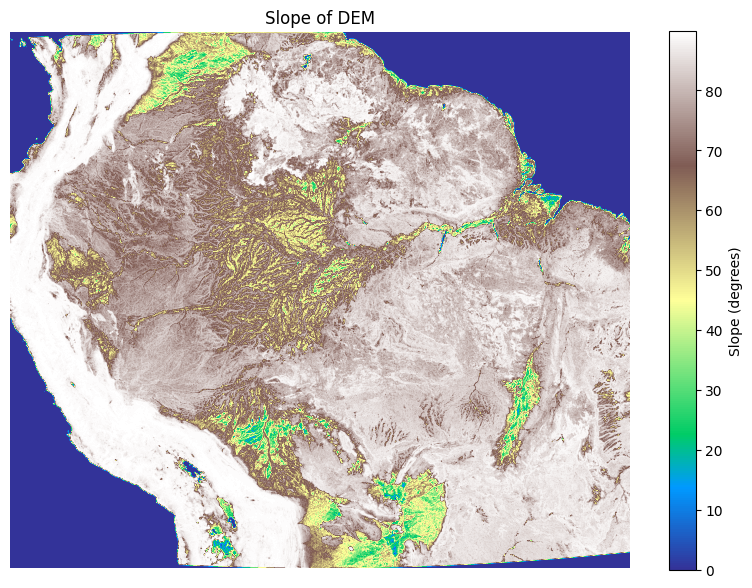

In [8]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from scipy import ndimage

# Read the DEM data
dem_path = '/kaggle/input/srtmdem2/SRTM_Elevation_Amazon.tif'  # Replace with the path to your DEM file

with rasterio.open(dem_path) as src:
    dem_data = src.read(1)  # Read the first band of the DEM
    dem_meta = src.meta     # Get metadata (CRS, transform, dtype, etc.)

# Step 1: Compute the slope (gradient)
# Define kernel size for computing gradients (use 3x3 kernel for simplicity)
x_gradient = np.gradient(dem_data, axis=1)  # Gradient in x (east-west direction)
y_gradient = np.gradient(dem_data, axis=0)  # Gradient in y (north-south direction)

# Compute slope in degrees
slope = np.arctan(np.sqrt(x_gradient**2 + y_gradient**2))  # In radians
slope_degrees = np.degrees(slope)  # Convert from radians to degrees

# Step 2: Save or display the slope image
# Update metadata for the output slope raster
slope_meta = dem_meta.copy()
slope_meta.update({
    'dtype': 'float32',  # Slope might require a floating-point data type
    'count': 1,  # Only one band (slope)
    'nodata': -9999  # NoData value
})


# If you want to visualize the slope raster
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.imshow(slope_degrees, cmap='terrain')  # Terrain colormap for elevation data
plt.colorbar(label='Slope (degrees)')
plt.title('Slope of DEM')
plt.axis('off')
plt.show()


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


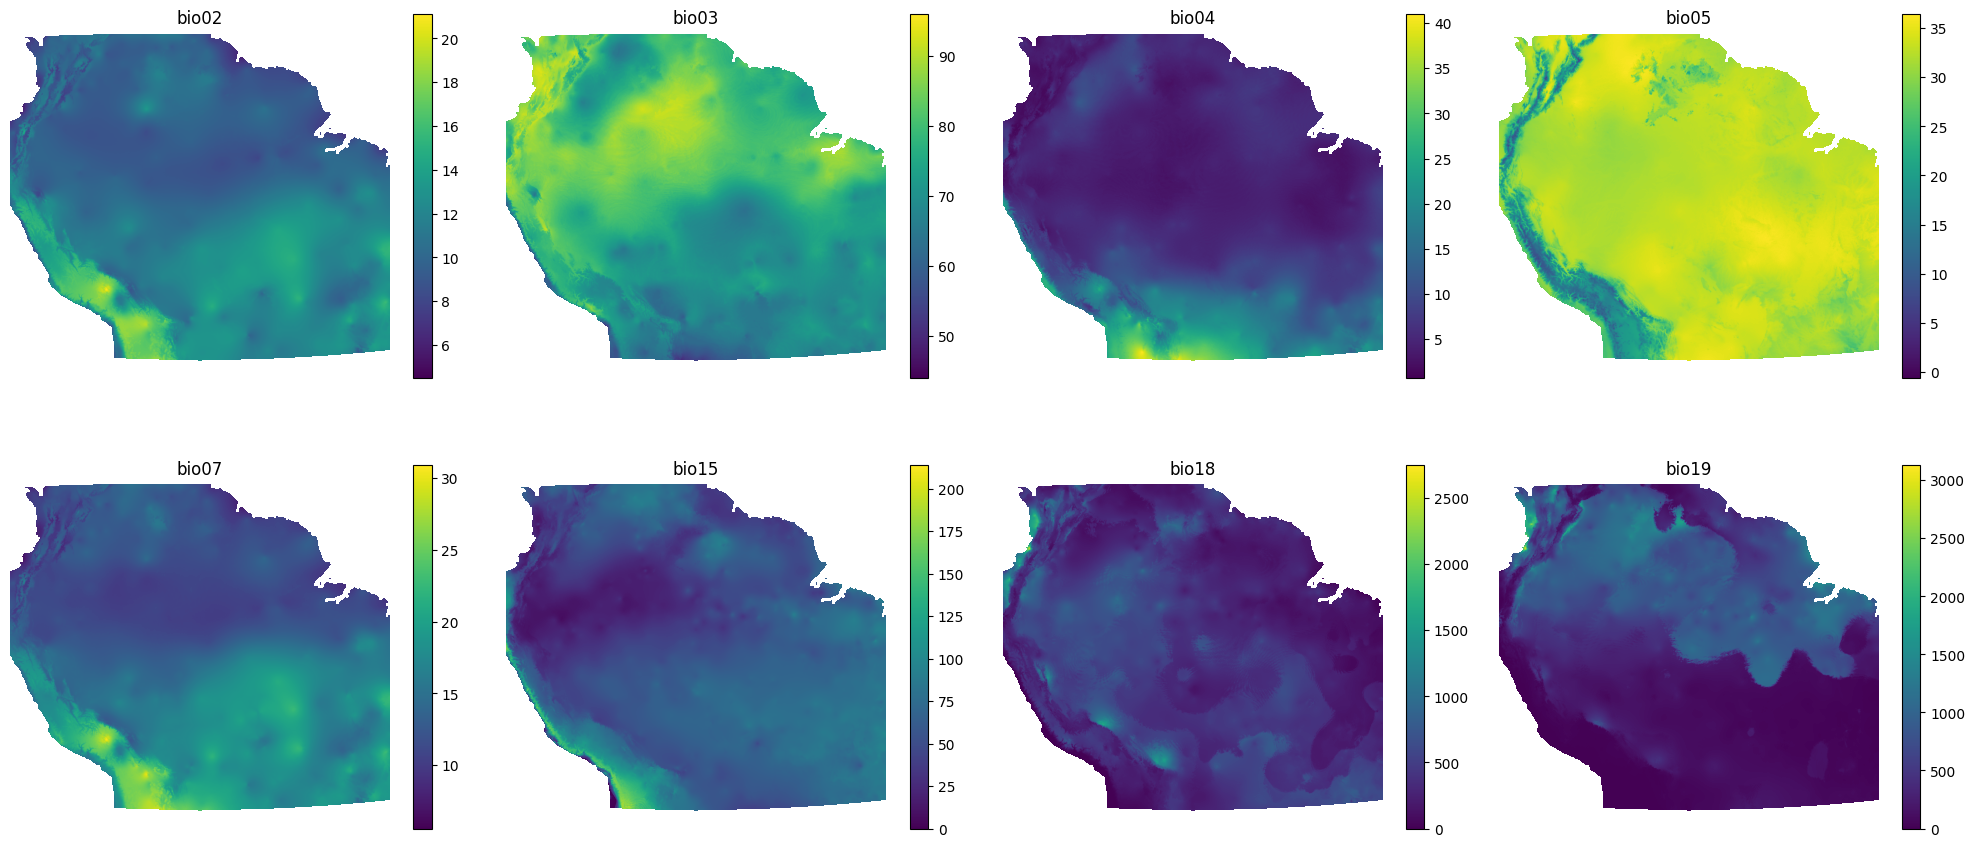

In [9]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Paths to your bioclimatic data
bio_paths = [
    '/kaggle/input/bioclims/bio02.tif',
    '/kaggle/input/bioclims/bio03.tif',
    '/kaggle/input/bioclims/bio04.tif',
    '/kaggle/input/bioclims/bio05.tif',
    '/kaggle/input/bioclims/bio07.tif',
    '/kaggle/input/bioclims/bio15.tif',
    '/kaggle/input/bioclims/bio18.tif',
    '/kaggle/input/bioclims/bio19.tif'
]

# Step 1: Load bioclimatic stack
bio_stack = []
for path in bio_paths:
    with rasterio.open(path) as src:
        bio_stack.append(src.read(1))  # Read the first band (assuming single band per file)
        ref_meta = src.meta  # Use first bio raster as reference for resampling

# Stack the bioclimatic variables
bio_stack = np.stack(bio_stack)

# Step 2: Visualize key layers of the bio_stack
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows, 4 columns for visualization
titles = ['bio02', 'bio03', 'bio04', 'bio05', 'bio07', 'bio15', 'bio18', 'bio19']

for i, ax in enumerate(axes.flat):
    im = ax.imshow(bio_stack[i], cmap='viridis')  # Display the raster data
    ax.set_title(titles[i])
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()


In [11]:
# Now, stack all layers together: bioclimatic variables, DEM, and slope
combined_stack = np.concatenate([
    bio_stack,            # Bioclimatic variables
    np.expand_dims(slope_resampled, axis=0),  # Add resampled slope as a new layer (1xHxW)
], axis=0)

# Check combined stack shape
print("Combined stack shape:", combined_stack.shape)


Combined stack shape: (9, 3396, 3920)


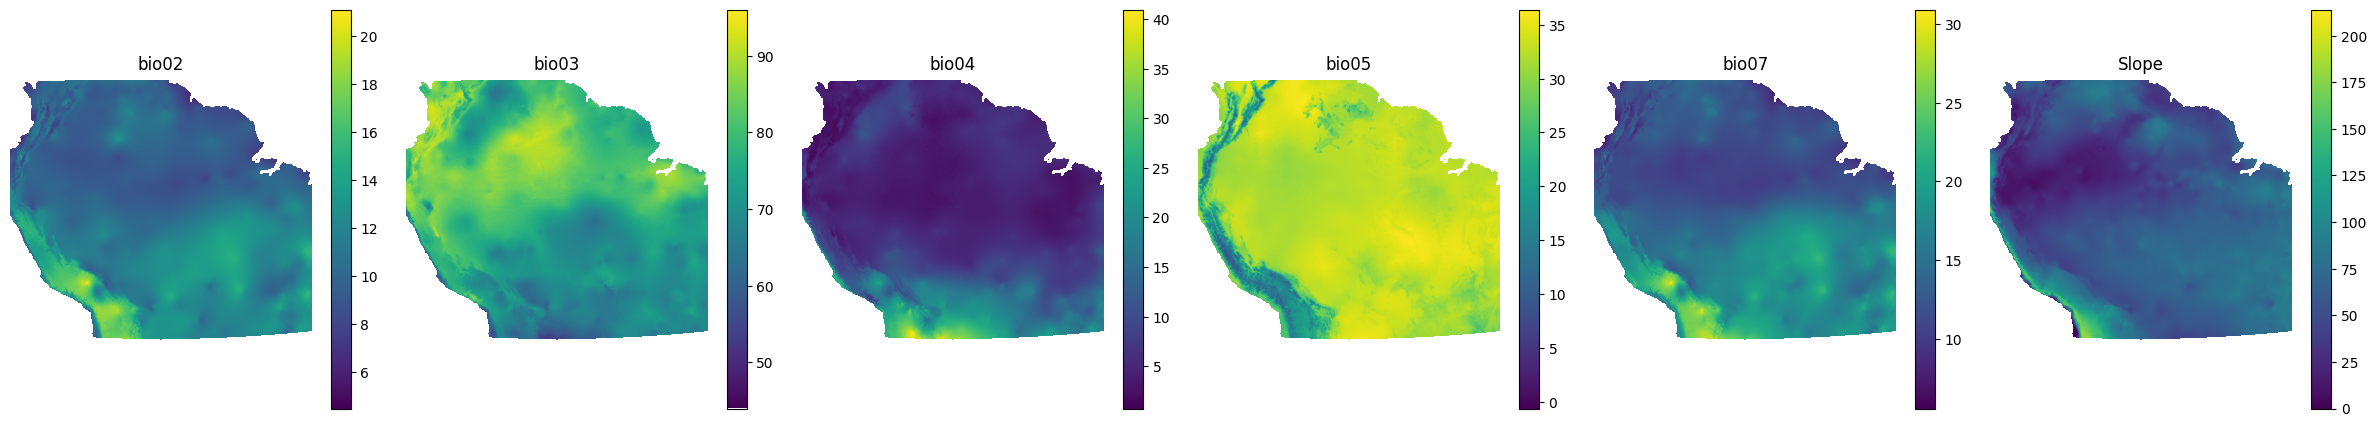

In [13]:
# Visualize the stacked data
fig, axes = plt.subplots(1, 6, figsize=(24, 6))
titles = ['bio02', 'bio03', 'bio04', 'bio05', 'bio07', 'Slope']  # Adjust titles accordingly
band_idx = [0, 1, 2, 3, 4, 5]  # Indices for the first 5 bio layers and the slope layer

for i, ax in enumerate(axes):
    im = ax.imshow(combined_stack[band_idx[i]], cmap='viridis')
    ax.set_title(titles[i])
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
gdf = pd.read_csv('/kaggle/input/archaeologicaltypes/filtered_points.csv')

In [15]:
gdf.tail()

,Id,type,POINT_X,POINT_Y
915,1382,geoglyphs,-67.135327,-9.698450
916,1383,geoglyphs,-66.910135,-10.027339
917,1384,geoglyphs,-66.859120,-9.889521
918,1385,geoglyphs,-66.950491,-9.783683
919,1386,geoglyphs,-67.062421,-9.730383


In [16]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [17]:
# Convert lat, lon into geometry (Point)
gdf['geometry'] = gdf.apply(lambda row: Point(row['POINT_X'], row['POINT_Y']), axis=1)

# Create GeoDataFrame and set CRS
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:4326')

# Check the first few rows
print(gdf.head())

   Id                   type    POINT_X    POINT_Y  \
0   0  large platform mounds -64.357915 -15.000864   
1   1  large platform mounds -64.774797 -14.983732   
2   2  large platform mounds -64.286531 -15.294966   
3   3  large platform mounds -64.343638 -15.172186   
4   4  large platform mounds -64.797639 -15.166475   

                      geometry  
0  POINT (-64.35792 -15.00086)  
1  POINT (-64.77480 -14.98373)  
2  POINT (-64.28653 -15.29497)  
3  POINT (-64.34364 -15.17219)  
4  POINT (-64.79764 -15.16648)  


In [41]:
# Step 3: Verify the GeoDataFrame
print(gdf.tail())
print(gdf.crs)

       Id       type    POINT_X    POINT_Y                     geometry
915  1382  geoglyphs -67.135327  -9.698450   POINT (-67.13533 -9.69845)
916  1383  geoglyphs -66.910135 -10.027339  POINT (-66.91013 -10.02734)
917  1384  geoglyphs -66.859120  -9.889521   POINT (-66.85912 -9.88952)
918  1385  geoglyphs -66.950491  -9.783683   POINT (-66.95049 -9.78368)
919  1386  geoglyphs -67.062421  -9.730383   POINT (-67.06242 -9.73038)
EPSG:4326


In [20]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from shapely.geometry import Point

# Assuming combined_stack has been created already as shown before

# Function to extract raster values at geoglyph points for combined_stack
def extract_raster_values_at_points(combined_stack, gdf, transform):
    values = []
    # Iterate over all geoglyph points
    for point in gdf.geometry:
        row, col = rowcol(transform, point.x, point.y)  # Get the row and column of each geoglyph
        # Extract values for each layer in the combined stack
        point_values = [combined_stack[i][row, col] for i in range(combined_stack.shape[0])]
        values.append(point_values)
    return values

# Assuming combined_stack is already created and 'transform' is the transform of one of the input rasters
# You can use any raster's transform (e.g., from the first bio raster)
with rasterio.open('/kaggle/input/bioclims/bio02.tif') as src:
    ref_transform = src.transform

# Extract raster values at geoglyph points
geoglyph_values = extract_raster_values_at_points(combined_stack, gdf, ref_transform)





In [21]:
# Assuming geoglyph_values contains 9 values (e.g., 8 bioclimatic variables + 1 slope)
columns = ['bio02', 'bio03', 'bio04', 'bio05', 'bio07', 'bio15', 'bio18', 'bio19', 'slope']

# Convert the extracted values to a DataFrame
geoglyph_features = pd.DataFrame(geoglyph_values, columns=columns)

# Check the resulting feature matrix
print(geoglyph_features)


     bio02  bio03  bio04  bio05  bio07  bio15  bio18  bio19  slope
0     11.5   66.0  16.00   33.4   17.3   57.0  776.0  154.0    0.0
1     11.3   64.0  16.41   33.4   17.4   57.0  619.0  160.0    0.0
2     11.4   66.0  17.23   33.2   17.2   56.0  621.0  178.0    0.0
3     11.4   65.0  16.93   33.4   17.4   57.0  614.0  168.0    0.0
4     11.3   64.0  17.26   33.2   17.4   56.0  651.0  180.0    0.0
..     ...    ...    ...    ...    ...    ...    ...    ...    ...
915   10.9   76.0   6.55   32.8   14.2   58.0  446.0  179.0    0.0
916   10.8   74.0   6.85   33.1   14.5   58.0  459.0  162.0    0.0
917   10.9   75.0   6.62   32.9   14.5   58.0  462.0  163.0    0.0
918   10.8   75.0   6.77   32.9   14.4   58.0  458.0  170.0    0.0
919   10.8   76.0   6.49   32.8   14.2   58.0  451.0  174.0    0.0

[920 rows x 9 columns]


In [33]:
# Compute mean and standard deviation across the 15 geoglyph locations
geoglyph_mean = geoglyph_features.mean(axis=0)
geoglyph_std = geoglyph_features.std(axis=0)

# Display the mean and standard deviation for each feature
print("Archaeological Signature Mean:\n", geoglyph_mean)
print("\nArchaeological Signature Standard Deviation:\n", geoglyph_std)


Archaeological Signature Mean:
 bio02     10.387826
bio03     77.004348
bio04      5.718598
bio05     32.900326
bio07     13.575217
bio15     56.342391
bio18    369.597826
bio19    503.079348
slope      0.000000
dtype: float64

Archaeological Signature Standard Deviation:
 bio02      1.377474
bio03      5.948087
bio04      2.121299
bio05      0.818921
bio07      2.647695
bio15     13.291294
bio18    154.051308
bio19    385.709119
slope      0.000000
dtype: float64


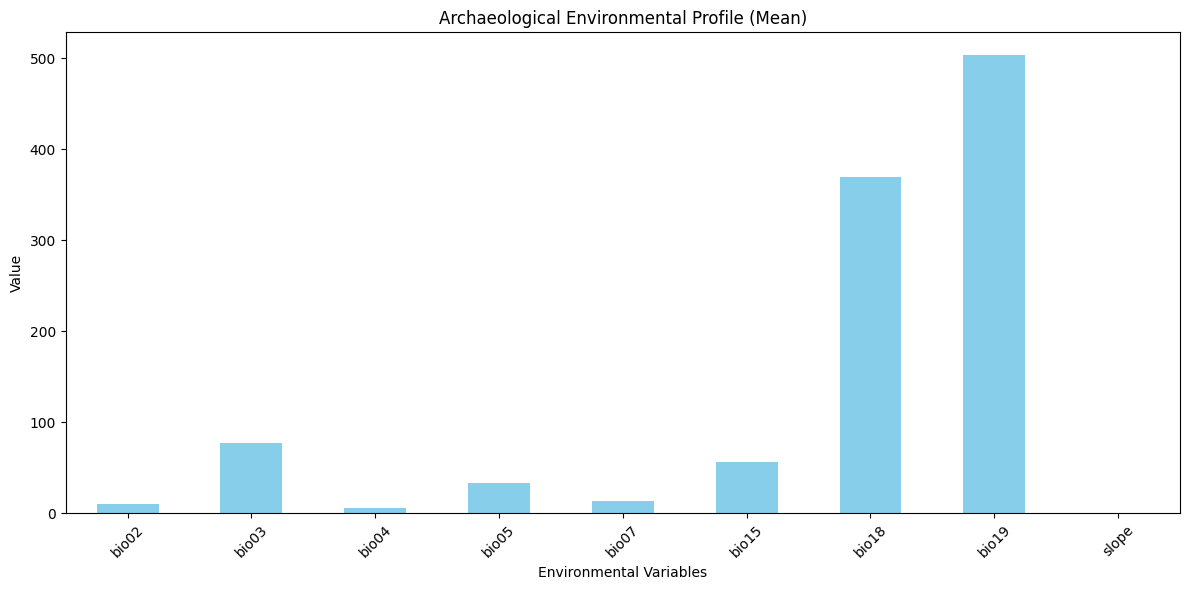

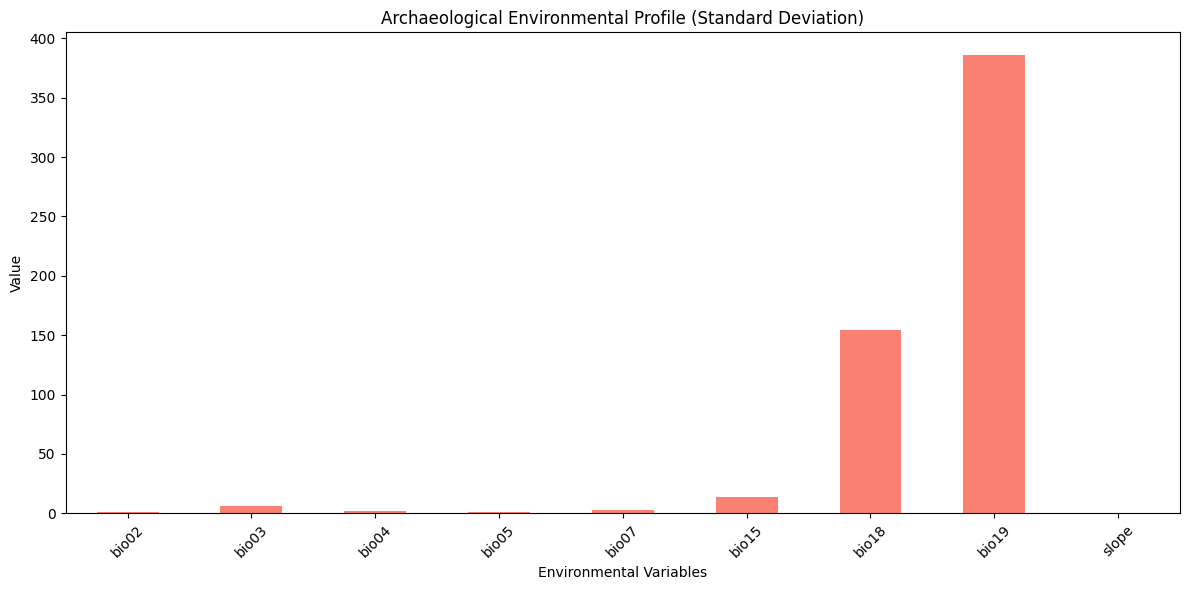

In [34]:
# Plot the mean values of the bioclimatic variables and slope
geoglyph_mean.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Archaeological Environmental Profile (Mean)')
plt.xlabel('Environmental Variables')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the standard deviation values for the geoglyphs
geoglyph_std.plot(kind='bar', figsize=(12, 6), color='salmon')
plt.title('Archaeological Environmental Profile (Standard Deviation)')
plt.xlabel('Environmental Variables')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


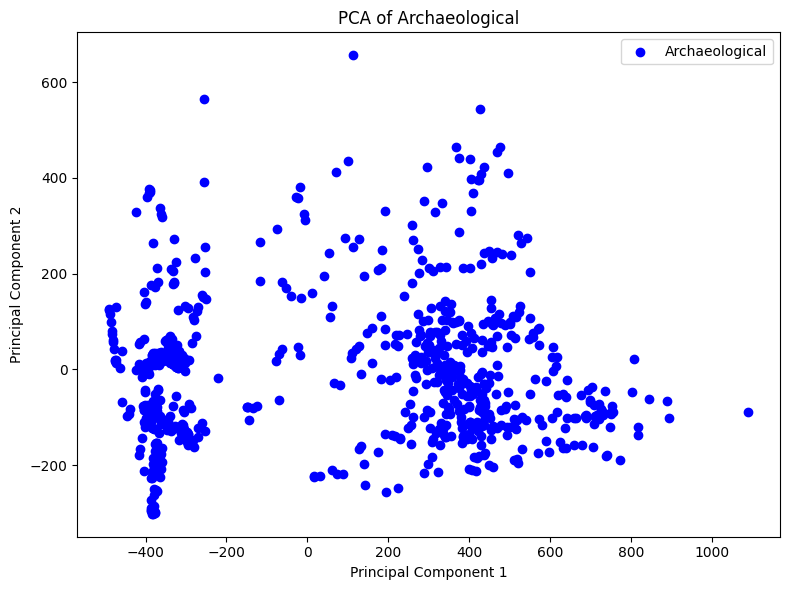

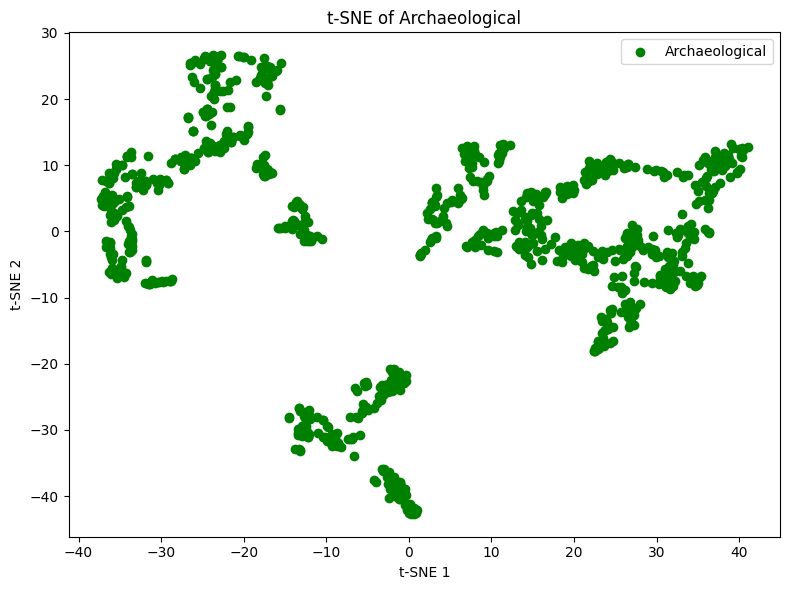

In [37]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(geoglyph_features)

# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', label='Archaeological')
plt.title('PCA of Archaeological')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

# Alternatively, apply t-SNE for visualization in a 2D latent space
tsne = TSNE(n_components=2)
tsne_result = tsne.fit_transform(geoglyph_features)

# Plot t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c='green', label='Archaeological')
plt.title('t-SNE of Archaeological')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()


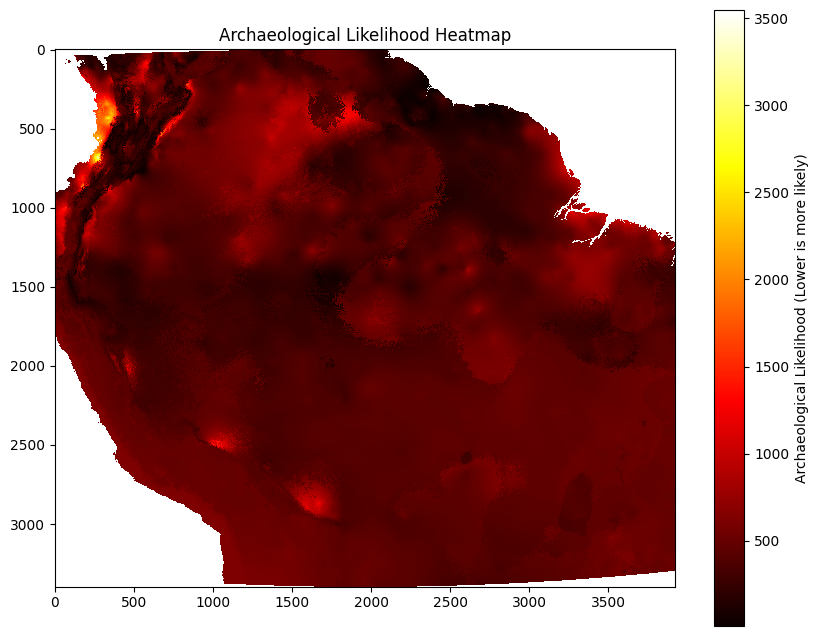

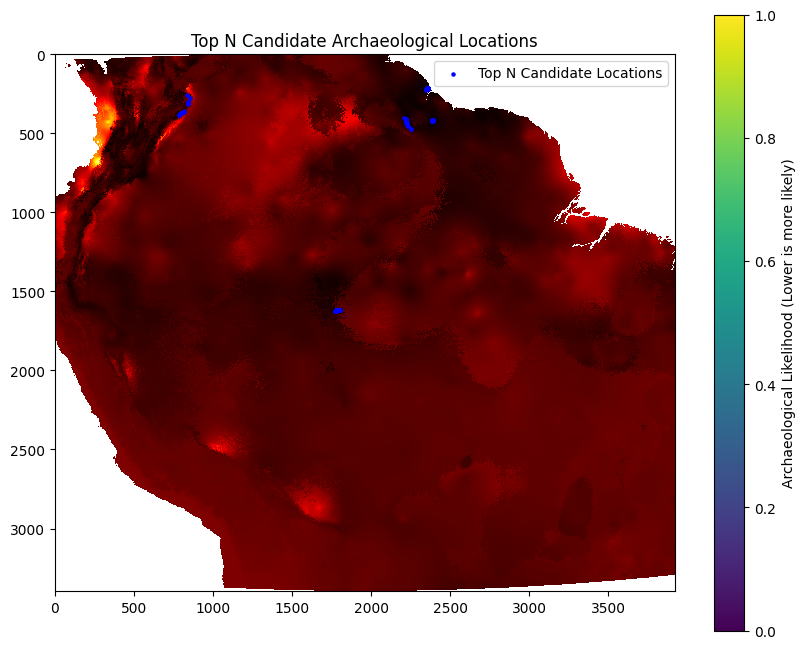

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


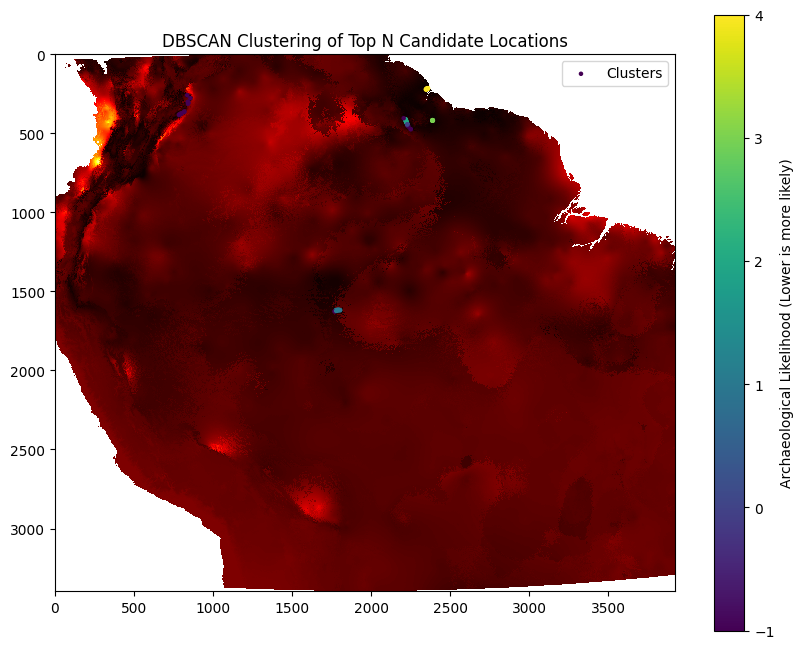

In [40]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from rasterio.transform import rowcol

# Step 1: Get the mean signature and its standard deviation
mean_signature = geoglyph_features.mean(axis=0)  # Mean across the geoglyph points
std_signature = geoglyph_features.std(axis=0)  # Standard deviation

# Step 2: Function to calculate Euclidean distance from geoglyph signature to all raster pixels
def calculate_euclidean_distance(combined_stack, mean_signature, std_signature):
    # Flatten combined_stack and calculate the Euclidean distance to the geoglyph mean signature
    flattened_stack = combined_stack.reshape((combined_stack.shape[0], -1)).T  # shape: (num_pixels, num_features)
    distance = cdist(flattened_stack, mean_signature.values.reshape(1, -1), metric='euclidean')
    return distance.reshape(combined_stack.shape[1], combined_stack.shape[2])

# Step 3: Calculate the Euclidean distance (Geoglyph Likelihood Heatmap)
geoglyph_likelihood_heatmap = calculate_euclidean_distance(combined_stack, mean_signature, std_signature)

# Step 4: Visualize the Geoglyph Likelihood Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(geoglyph_likelihood_heatmap, cmap='hot', interpolation='nearest')
plt.colorbar(label="Archaeological Likelihood (Lower is more likely)")
plt.title("Archaeological Likelihood Heatmap")
plt.show()

# Step 5: Extract Top N Candidate Locations (e.g., top 100 most likely pixels)
top_n = 100  # Choose the top N (e.g., 100)
top_n_indices = np.unravel_index(np.argsort(geoglyph_likelihood_heatmap.ravel())[:top_n], geoglyph_likelihood_heatmap.shape)

# Plot the top N candidate locations on the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(geoglyph_likelihood_heatmap, cmap='hot', interpolation='nearest')
plt.scatter(top_n_indices[1], top_n_indices[0], color='blue', s=5, label="Top N Candidate Locations")
plt.colorbar(label="Archaeological Likelihood (Lower is more likely)")
plt.title("Top N Candidate Archaeological Locations")
plt.legend()
plt.show()

# Step 6: Apply DBSCAN to cluster the candidate locations
coordinates = np.column_stack(top_n_indices)
db = DBSCAN(eps=5, min_samples=5).fit(coordinates)

# Step 7: Visualize the clustering results
plt.figure(figsize=(10, 8))
plt.imshow(geoglyph_likelihood_heatmap, cmap='hot', interpolation='nearest')
plt.scatter(coordinates[:, 1], coordinates[:, 0], c=db.labels_, cmap='viridis', s=5, label="Clusters")
plt.colorbar(label="Archaeological Likelihood (Lower is more likely)")
plt.title("DBSCAN Clustering of Top N Candidate Locations")
plt.legend()
plt.show()


/tmp/ipykernel_35/49586140.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(types))  # Use a colormap to differentiate types


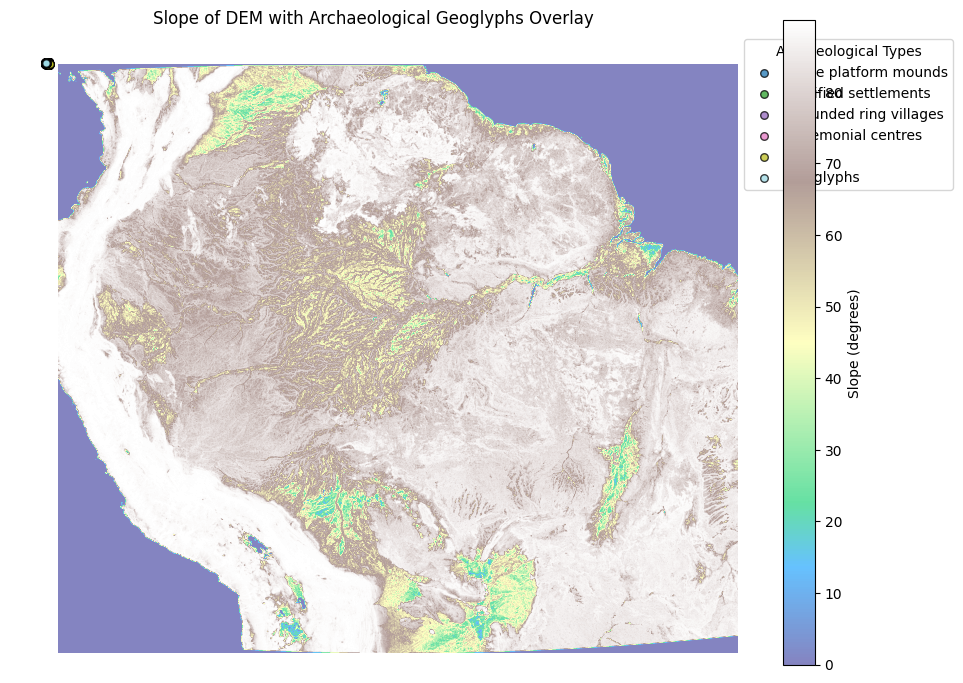

In [49]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Assuming gdf is the GeoDataFrame and 'combined_stack' and 'slope_degrees' are ready

# Plot the Slope Map
plt.figure(figsize=(10, 7))
plt.imshow(slope_degrees, cmap='terrain', alpha=0.6)  # Adjust alpha for transparency of background map
plt.colorbar(label='Slope (degrees)')
plt.title('Slope of DEM with Archaeological Geoglyphs Overlay')
plt.axis('off')

# Overlay geoglyph points on top of the slope map
x_coords = gdf['POINT_X']
y_coords = gdf['POINT_Y']

# Get the unique archaeological types for color-coding
types = gdf['type'].unique()
colors = plt.cm.get_cmap('tab20', len(types))  # Use a colormap to differentiate types

# Plot each type with a different color and add markers
for i, archeo_type in enumerate(types):
    type_mask = gdf['type'] == archeo_type
    plt.scatter(x_coords[type_mask], y_coords[type_mask], label=archeo_type, 
                color=colors(i), s=30, edgecolor='black', alpha=0.75, marker='o')

# Add legend to differentiate between types
plt.legend(title="Archaeological Types", loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.tight_layout()
plt.show()


gdf CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
DEM CRS: EPSG:4326
Geoglyph Coordinates:
   Id                   type    POINT_X    POINT_Y  \
0   0  large platform mounds -64.357915 -15.000864   
1   1  large platform mounds -64.774797 -14.983732   
2   2  large platform mounds -64.286531 -15.294966   
3   3  large platform mounds -64.343638 -15.172186   
4   4  large platform mounds -64.797639 -15.166475   

                      geometry  
0  POINT (-64.35792 -15.00086)  
1  POINT (-64.77480 -14.98373)  
2  POINT (-64.28653 -15.29497)  
3  POINT (-64.34364 -15.17219)  
4  POINT (-64.79764 -15.16648)  
Point: (-64.357915, -15.000864) -> Row: 2681, Col: 1708
Point: (-64.774797, -14.983732) -> Row: 2679, Col: 1662
Point: (-64.

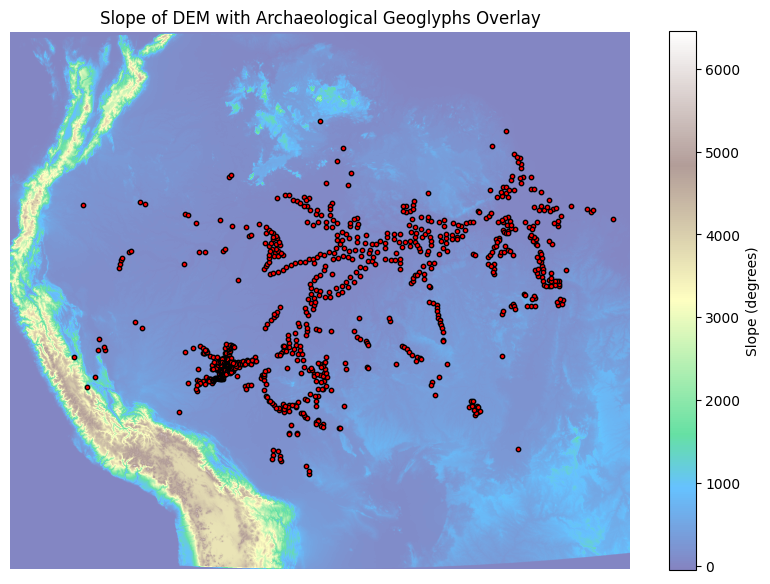

In [52]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from rasterio.transform import rowcol

# Read the DEM data for slope calculation (already done)
with rasterio.open(dem_path) as src:
    dem_data = src.read(1)  # Read the DEM band
    dem_meta = src.meta     # Get metadata (crs, transform, dtype, etc.)
    dem_transform = src.transform  # Raster's affine transform
    dem_crs = src.crs  # Raster CRS

# Ensure gdf is in the same CRS as the DEM
gdf = gdf.to_crs(dem_crs)  # Ensure the geoglyph points are in the same CRS as the DEM

# Debug: Print CRS of gdf and DEM to verify they are the same
print(f"gdf CRS: {gdf.crs}")
print(f"DEM CRS: {dem_crs}")

# Debug: Print first few geoglyph coordinates to check their correctness
print("Geoglyph Coordinates:")
print(gdf.head())

# Function to convert geoglyph lat/lon into row/col in raster space
def lat_lon_to_pixel(transform, x, y):
    # Convert coordinates (x, y) in world space to row, col in raster space
    row, col = rowcol(transform, x, y)
    return row, col

# Plot the DEM slope and overlay points
plt.figure(figsize=(10, 7))
plt.imshow(dem_data, cmap='terrain', alpha=0.6)  # Plot the DEM slope with transparency
plt.colorbar(label='Slope (degrees)')
plt.title('Slope of DEM with Archaeological Geoglyphs Overlay')
plt.axis('off')

# Get the x and y coordinates of the geoglyphs from the gdf
x_coords = gdf.geometry.x
y_coords = gdf.geometry.y

# Convert these coordinates to row, col in raster space and plot on top of the DEM
for x, y in zip(x_coords, y_coords):
    row, col = lat_lon_to_pixel(dem_transform, x, y)  # Get row/col for the point
    # Debug: Print the converted row, col
    print(f"Point: ({x}, {y}) -> Row: {row}, Col: {col}")
    
    # Plot the point (ensure it's inside the image)
    if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
        plt.scatter(col, row, color='red', s=10, edgecolor='black', label='Geoglyph')

#


/tmp/ipykernel_35/2595556562.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(types))  # Use tab20 colormap for multiple types


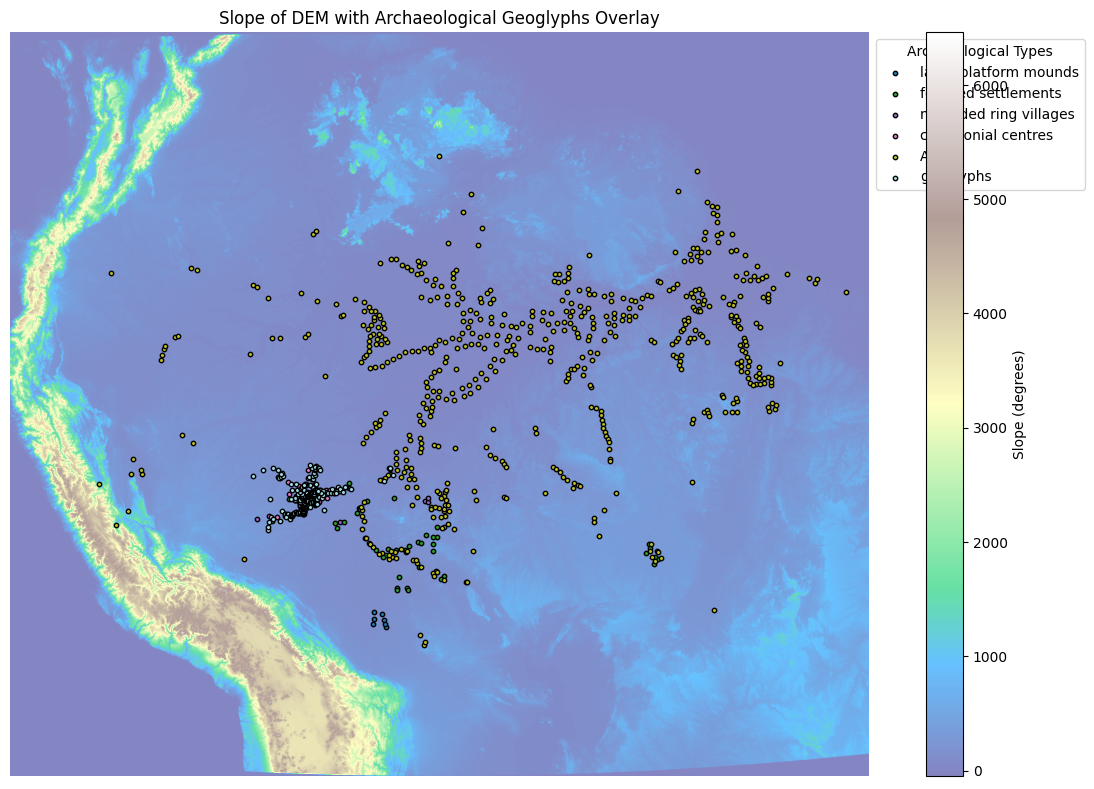

In [53]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rasterio
from shapely.geometry import Point
from rasterio.transform import rowcol

# Assuming combined_stack has already been created and loaded.
# Assuming 'gdf' is your geospatial dataframe containing archaeological points with a 'type' column.

# Read DEM for slope calculation (already done)
with rasterio.open(dem_path) as src:
    dem_data = src.read(1)  # Read the DEM band
    dem_transform = src.transform  # Get the affine transform of the DEM
    dem_crs = src.crs  # CRS of DEM

# Function to convert geoglyph lat/lon into row/col in raster space
def lat_lon_to_pixel(transform, x, y):
    # Convert coordinates (x, y) in world space to row, col in raster space
    row, col = rowcol(transform, x, y)
    return row, col

# Function to get color map for archaeological types
def get_colormap():
    # Create a colormap based on the types of archaeological sites
    types = gdf['type'].unique()  # Get unique types from the gdf
    colors = plt.cm.get_cmap('tab20', len(types))  # Use tab20 colormap for multiple types
    type_colors = {t: colors(i) for i, t in enumerate(types)}  # Map types to colors
    return type_colors

# Plot the DEM slope map
plt.figure(figsize=(12, 8))
plt.imshow(dem_data, cmap='terrain', alpha=0.6)  # Plot DEM with transparency
plt.colorbar(label='Slope (degrees)')
plt.title('Slope of DEM with Archaeological Geoglyphs Overlay')
plt.axis('off')

# Get the x and y coordinates of the geoglyphs from the gdf
x_coords = gdf.geometry.x
y_coords = gdf.geometry.y

# Get the color map for the types
type_colors = get_colormap()

# Plot the points with colors based on their type
for x, y, t in zip(x_coords, y_coords, gdf['type']):
    row, col = lat_lon_to_pixel(dem_transform, x, y)  # Get row/col for the point
    
    if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
        # Plot the point with the color corresponding to its type
        plt.scatter(col, row, color=type_colors[t], s=10, edgecolor='black', label=t)

# Remove duplicate labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Archaeological Types", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


/tmp/ipykernel_35/3408036797.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(types))  # Use 'tab20' colormap for different types


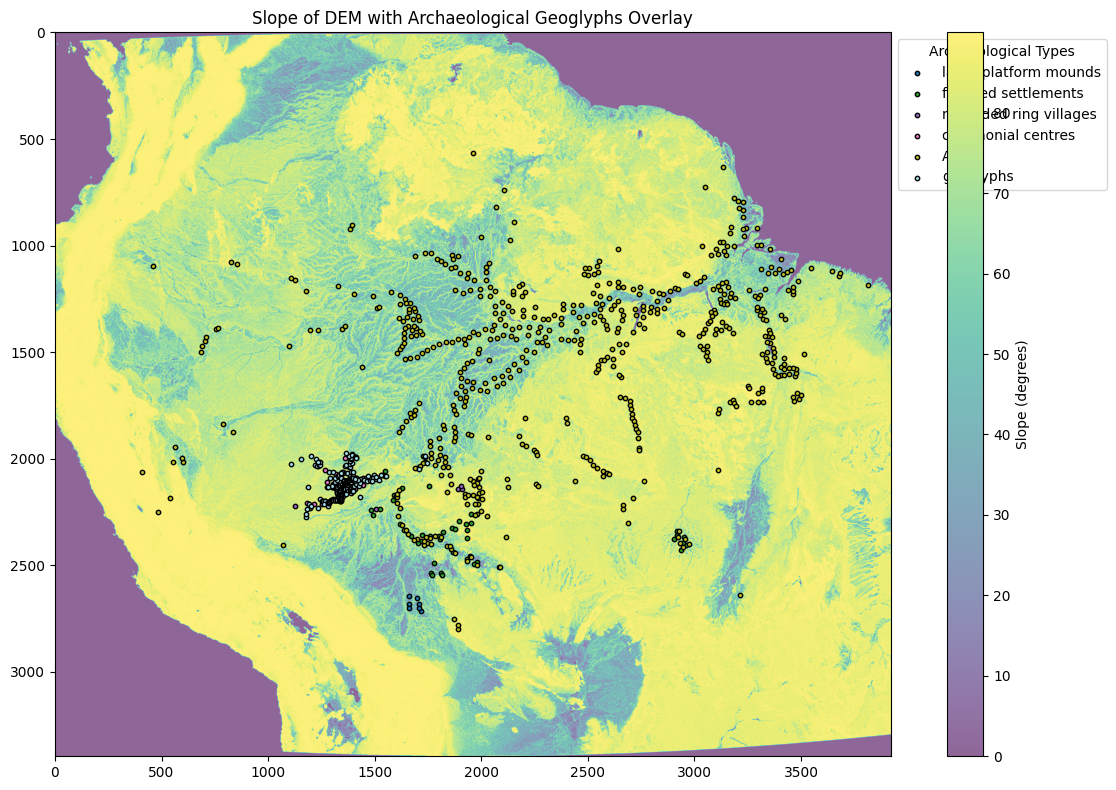

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely.geometry import Point
from rasterio.transform import rowcol

# Assuming you already have combined_stack, gdf, and other variables loaded.

# Read the DEM data for slope calculation
with rasterio.open(dem_path) as src:
    dem_data = src.read(1)  # Read DEM band
    dem_transform = src.transform  # Get the affine transform of the DEM
    dem_crs = src.crs  # CRS of DEM

# Function to convert geoglyph lat/lon into row/col in raster space
def lat_lon_to_pixel(transform, x, y):
    row, col = rowcol(transform, x, y)  # Convert coordinates (x, y) in world space to row, col in raster space
    return row, col

# Compute slope (already done in previous code)
x_gradient = np.gradient(dem_data, axis=1)
y_gradient = np.gradient(dem_data, axis=0)
slope = np.arctan(np.sqrt(x_gradient**2 + y_gradient**2))
slope_degrees = np.degrees(slope)

# Plot the DEM slope
plt.figure(figsize=(12, 8))
plt.imshow(slope_degrees, cmap='viridis', alpha=0.6)  # Use 'viridis' colormap for slope
plt.colorbar(label='Slope (degrees)')
plt.title('Slope of DEM with Archaeological Geoglyphs Overlay')

# Get the x and y coordinates of the geoglyphs from the gdf
x_coords = gdf.geometry.x
y_coords = gdf.geometry.y

# Get unique types of archaeological sites
types = gdf['type'].unique()
colors = plt.cm.get_cmap('tab20', len(types))  # Use 'tab20' colormap for different types
type_colors = {t: colors(i) for i, t in enumerate(types)}  # Map types to colors

# Plot the points with colors based on their type
for x, y, t in zip(x_coords, y_coords, gdf['type']):
    row, col = lat_lon_to_pixel(dem_transform, x, y)  # Get row/col for each point
    
    if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
        # Plot the point with the color corresponding to its type
        plt.scatter(col, row, color=type_colors[t], s=10, edgecolor='black', label=t)

# Remove duplicate labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Archaeological Types", loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_35/1900365071.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(types))  # Use 'tab20' colormap for different types


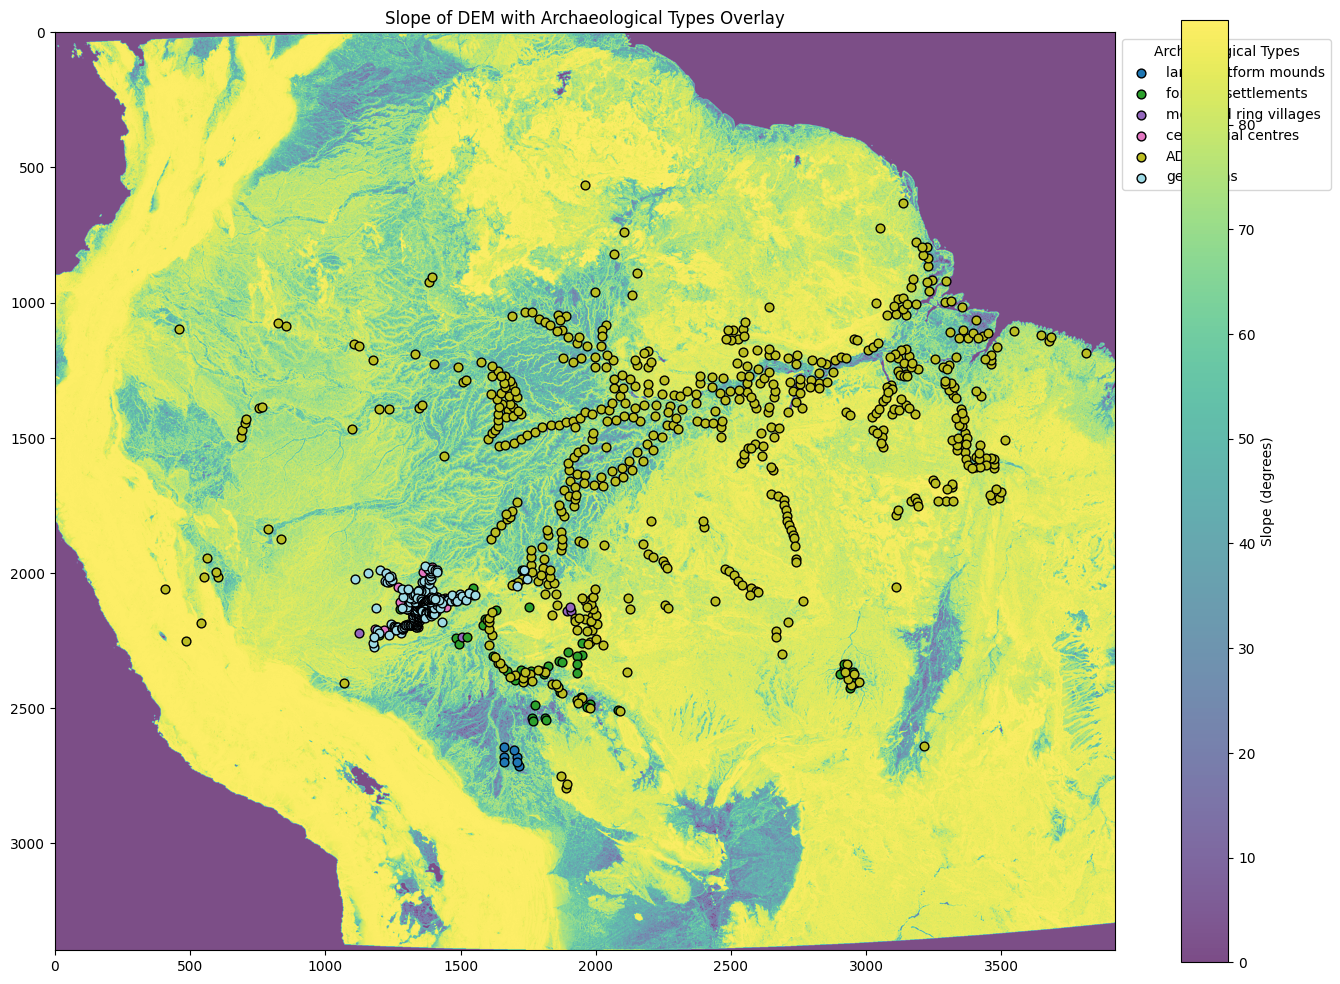

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from shapely.geometry import Point

# Assuming the previous steps for loading gdf and DEM

# Read the DEM data for slope calculation
with rasterio.open(dem_path) as src:
    dem_data = src.read(1)  # Read DEM band
    dem_transform = src.transform  # Get the affine transform of the DEM
    dem_crs = src.crs  # CRS of DEM

# Compute slope (already done in previous code)
x_gradient = np.gradient(dem_data, axis=1)
y_gradient = np.gradient(dem_data, axis=0)
slope = np.arctan(np.sqrt(x_gradient**2 + y_gradient**2))
slope_degrees = np.degrees(slope)

# Set up the map
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the DEM slope
cax = ax.imshow(slope_degrees, cmap='viridis', alpha=0.7)  # Apply colormap to slope data
fig.colorbar(cax, ax=ax, label='Slope (degrees)')  # Add colorbar for slope

ax.set_title('Slope of DEM with Archaeological Types Overlay')

# Get unique types of archaeological sites
types = gdf['type'].unique()
colors = plt.cm.get_cmap('tab20', len(types))  # Use 'tab20' colormap for different types
type_colors = {t: colors(i) for i, t in enumerate(types)}  # Map types to colors

# Plot points from gdf with color based on 'type'
for x, y, t in zip(gdf.geometry.x, gdf.geometry.y, gdf['type']):
    row, col = rowcol(dem_transform, x, y)  # Convert lat/lon to row/col in raster
    if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
        ax.scatter(col, row, color=type_colors[t], s=40, edgecolor='black', label=t)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Archaeological Types", loc='upper left', bbox_to_anchor=(1, 1))

# Ensure tight layout to prevent overlap
plt.tight_layout()
plt.show()
